In [3]:
import os
print(os.getcwd())


C:\Users\kedri\nlp_course\nlp_env\Scripts\datasetBee


In [4]:
 #Load the Dataset
import pandas as pd

data_path = "all_data_updated.csv"
df = pd.read_csv(data_path)

# Display the first few rows of the dataset
df.head()


,device,hive number,date,hive temp,hive humidity,hive pressure,weather temp,weather humidity,weather pressure,wind speed,...,rain,lat,long,file name,queen presence,queen acceptance,frames,target,time,queen status
0,1,5,2022-06-08 14:52:28,36.42,30.29,1007.45,26.68,52,1013,8.75,...,0,37.29,-121.95,2022-06-08--14-52-28_1.raw,1,2,8,0,0.583,0
1,1,5,2022-06-08 15:51:41,33.56,33.98,1006.93,25.99,53,1012,10.29,...,0,37.29,-121.95,2022-06-08--15-51-41_1.raw,1,2,8,0,0.625,0
2,1,5,2022-06-08 17:21:53,29.01,42.73,1006.68,24.49,56,1012,8.75,...,0,37.29,-121.95,2022-06-08--17-21-53_1.raw,0,0,8,1,0.708,1
3,1,5,2022-06-08 18:20:59,30.51,36.74,1006.68,22.97,59,1012,8.23,...,0,37.29,-121.95,2022-06-08--18-20-59_1.raw,0,0,8,1,0.750,1
4,1,5,2022-06-08 19:20:04,30.32,35.55,1006.58,21.52,61,1012,7.20,...,0,37.29,-121.95,2022-06-08--19-20-04_1.raw,0,0,8,1,0.792,1


In [5]:
print(df.columns)

Index(['device', 'hive number', 'date', 'hive temp', 'hive humidity',
       'hive pressure', 'weather temp', 'weather humidity', 'weather pressure',
       'wind speed', 'gust speed', 'weatherID', 'cloud coverage', 'rain',
       'lat', 'long', 'file name', 'queen presence', 'queen acceptance',
       'frames', 'target', 'time', 'queen status'],
      dtype='object')


In [6]:
print(df.head())  # See the first few rows


   device  hive number                 date  hive temp  hive humidity  \
0       1            5  2022-06-08 14:52:28      36.42          30.29   
1       1            5  2022-06-08 15:51:41      33.56          33.98   
2       1            5  2022-06-08 17:21:53      29.01          42.73   
3       1            5  2022-06-08 18:20:59      30.51          36.74   
4       1            5  2022-06-08 19:20:04      30.32          35.55   

   hive pressure  weather temp  weather humidity  weather pressure  \
0        1007.45         26.68                52              1013   
1        1006.93         25.99                53              1012   
2        1006.68         24.49                56              1012   
3        1006.68         22.97                59              1012   
4        1006.58         21.52                61              1012   

   wind speed  ...  rain    lat    long                   file name  \
0        8.75  ...     0  37.29 -121.95  2022-06-08--14-52-28_1.raw  

In [7]:
import os
import pandas as pd
#List and Process WAV Audio Files
audio_folder = "sound_files/"
file_names = [f for f in os.listdir(audio_folder) if f.endswith('.wav')]

# Create a DataFrame from the file names
df= pd.DataFrame(file_names, columns=['file name'])
df['file name'] = df['file name'].apply(lambda x: x.split('/')[-1])  

print(df.head())  


                              file name
0  2022-06-05--17-41-01_2__segment1.wav
1  2022-06-05--17-41-01_2__segment2.wav
2  2022-06-05--17-41-01_2__segment3.wav
3  2022-06-05--17-41-01_2__segment4.wav
4  2022-06-05--17-41-01_2__segment5.wav


In [8]:
import librosa
import numpy as np
import os
import pandas as pd
# Path to audio files
audio_folder = "sound_files/"
# Ensure the 'file name' column contains correct file names with '.wav' extension
df['file name'] = df['file name'].apply(lambda x: x.replace('.raw', '.wav') if '.raw' in x else x)

# Function to extract MFCC features
def extract_mfcc(file_name):
    file_path = os.path.join(audio_folder, file_name)
    try:
        y, sr = librosa.load(file_path, sr=None) #y: The audio time series.sr: The sampling rate of the audio.
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        return np.mean(mfccs.T, axis=0)
    except Exception as e:
        print(f"Error loading {file_name}: {e}")
        return None
# Apply MFCC extraction
df['mfcc_features'] = df['file name'].apply(extract_mfcc)

# Drop rows where MFCC extraction failed
df= df[df['mfcc_features'].notnull()]

# Verify the feature extraction
print(df[['file name', 'mfcc_features']].head())

                              file name  \
0  2022-06-05--17-41-01_2__segment1.wav   
1  2022-06-05--17-41-01_2__segment2.wav   
2  2022-06-05--17-41-01_2__segment3.wav   
3  2022-06-05--17-41-01_2__segment4.wav   
4  2022-06-05--17-41-01_2__segment5.wav   

                                       mfcc_features  
0  [-237.70448, 193.00702, -8.558358, 41.322647, ...  
1  [-241.22339, 194.67253, -9.948501, 43.431095, ...  
2  [-237.79906, 194.8327, -8.357773, 42.13548, -2...  
3  [-235.91174, 192.79495, -5.7178154, 41.1548, -...  
4  [-242.84256, 198.904, -11.313543, 44.28095, -2...  


In [9]:
print(df[['file name', 'mfcc_features']].head())
# extracted the MFCC features for each audio file. The df_cleaned DataFrame now contains:
# file name: The name of the audio file (e.g., 2022-06-05--17-41-01_2__segment1.wav).
# mfcc_features: A list (or array) of 13 MFCC values for each file. These values represent the features extracted from the audio, which are used for audio analysis tasks such as classification or clustering.

                              file name  \
0  2022-06-05--17-41-01_2__segment1.wav   
1  2022-06-05--17-41-01_2__segment2.wav   
2  2022-06-05--17-41-01_2__segment3.wav   
3  2022-06-05--17-41-01_2__segment4.wav   
4  2022-06-05--17-41-01_2__segment5.wav   

                                       mfcc_features  
0  [-237.70448, 193.00702, -8.558358, 41.322647, ...  
1  [-241.22339, 194.67253, -9.948501, 43.431095, ...  
2  [-237.79906, 194.8327, -8.357773, 42.13548, -2...  
3  [-235.91174, 192.79495, -5.7178154, 41.1548, -...  
4  [-242.84256, 198.904, -11.313543, 44.28095, -2...  


In [12]:
#Check the Shape of the DataFrame
print(df.columns)
print(df.shape)


Index(['file name', 'mfcc_features'], dtype='object')
(5078, 2)


In [13]:
#Explore the MFCC Features
print(df['mfcc_features'].head())


0    [-237.70448, 193.00702, -8.558358, 41.322647, ...
1    [-241.22339, 194.67253, -9.948501, 43.431095, ...
2    [-237.79906, 194.8327, -8.357773, 42.13548, -2...
3    [-235.91174, 192.79495, -5.7178154, 41.1548, -...
4    [-242.84256, 198.904, -11.313543, 44.28095, -2...
Name: mfcc_features, dtype: object


In [14]:
#'mfcc_features' column to confirm it contains numerical data
print(df['mfcc_features'].iloc[0])

[-237.70448    193.00702     -8.558358    41.322647   -21.579601
   29.330574   -17.22555     17.298279   -12.431765    -3.122567
   -4.950906    -9.767395     1.8544619]


In [15]:
# Dimensions of the dataset
print(f"Dataset dimensions: {df.shape}")

Dataset dimensions: (5078, 2)


In [16]:
# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078 entries, 0 to 5077
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   file name      5078 non-null   object
 1   mfcc_features  5078 non-null   object
dtypes: object(2)
memory usage: 79.5+ KB


In [17]:
# Statistical summary for numerical features
mfcc_df = pd.DataFrame(df['mfcc_features'].tolist())  # Expand the list of features into separate columns
print(mfcc_df.describe())

                0            1            2            3            4   \
count  5078.000000  5078.000000  5078.000000  5078.000000  5078.000000   
mean   -251.572845   175.706558    -6.499869    47.913231   -19.326143   
std      30.009474    18.280537    15.112763    13.325657    10.452181   
min    -325.024292   112.122459   -54.734104     7.893683   -45.500580   
25%    -271.653831   165.902996   -16.236341    39.904538   -25.608746   
50%    -254.933952   178.560631    -8.586597    49.554981   -21.737936   
75%    -234.059116   187.470020     1.040445    57.700198   -16.696329   
max     -77.081787   225.894165    38.122959    77.922180     9.283252   

                5            6            7            8            9   \
count  5078.000000  5078.000000  5078.000000  5078.000000  5078.000000   
mean     26.596775   -11.181487    15.319337    -7.059104    -2.113594   
std       8.423235     6.863473     5.105119     3.516917     2.443361   
min      -0.692598   -31.667564    -3

In [18]:
# Count missing values in each column
print(df.isnull().sum())

file name        0
mfcc_features    0
dtype: int64


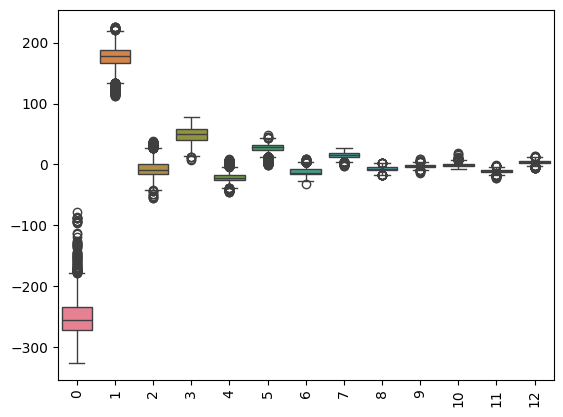

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
#detect potential outliers in numerical data.
# Plot boxplots for each MFCC feature
sns.boxplot(data=mfcc_df)
plt.xticks(rotation=90)
plt.show()

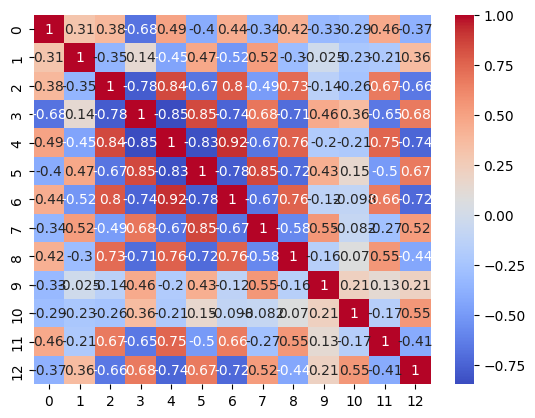

In [20]:
# Correlation matrix for MFCC features
sns.heatmap(mfcc_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [21]:
print(df.columns)

Index(['file name', 'mfcc_features'], dtype='object')


In [ ]:
#Output EMPTY DATA FRAME
import pandas as pd
# Load the original dataset with target and other columns
df_all_data = pd.read_csv("all_data_updated.csv")

# Load the dataset with MFCC features
df_mfcc = pd.DataFrame(file_names, columns=['file name'])
df_mfcc['mfcc_features'] = df_mfcc['file name'].apply(extract_mfcc)

# Merge the datasets on the 'file name' column
#df_merged = pd.merge(df_all_data, df_mfcc, on='file name', how='inner')

# Check the merged DataFrame
#print(df_merged.head())


In [26]:
# Check the unique values in 'file name' in both datasets
print(df_all_data['file name'].unique())
print(df_mfcc['file name'].unique())


['2022-06-08--14-52-28_1.raw' '2022-06-08--15-51-41_1.raw'
 '2022-06-08--17-21-53_1.raw' ... '2022-07-15--13-25-58_2.raw'
 '2022-07-15--14-24-58_2.raw' '2022-07-15--15-28-21_2.raw']
['2022-06-05--17-41-01_2__segment1.wav'
 '2022-06-05--17-41-01_2__segment2.wav'
 '2022-06-05--17-41-01_2__segment3.wav' ...
 '2022-07-15--15-28-21_2__segment0.wav'
 '2022-07-15--15-28-21_2__segment3.wav'
 '2022-07-15--15-28-21_2__segment4.wav']


In [29]:
#Adjusting File Names in One DataFrame
# Ensure that both datasets have consistent file extensions
df_mfcc['file name'] = df_mfcc['file name'].apply(lambda x: x.replace('.wav', '.raw') if '.wav' in x else x)

In [30]:
print("df_all_data shape:", df_all_data.shape)
print("df_mfcc shape:", df_mfcc.shape)
print("df_merged shape:", df_merged.shape)


df_all_data shape: (1275, 23)
df_mfcc shape: (5078, 2)
df_merged shape: (0, 24)


In [31]:
print(df_merged.head())


Empty DataFrame
Columns: [device, hive number, date, hive temp, hive humidity, hive pressure, weather temp, weather humidity, weather pressure, wind speed, gust speed, weatherID, cloud coverage, rain, lat, long, file name, queen presence, queen acceptance, frames, target, time, queen status, mfcc_features]
Index: []

[0 rows x 24 columns]


In [32]:
print(df_all_data['file name'].head())
print(df_mfcc['file name'].head())


0    2022-06-08--14-52-28_1.raw
1    2022-06-08--15-51-41_1.raw
2    2022-06-08--17-21-53_1.raw
3    2022-06-08--18-20-59_1.raw
4    2022-06-08--19-20-04_1.raw
Name: file name, dtype: object
0    2022-06-05--17-41-01_2__segment1.raw
1    2022-06-05--17-41-01_2__segment2.raw
2    2022-06-05--17-41-01_2__segment3.raw
3    2022-06-05--17-41-01_2__segment4.raw
4    2022-06-05--17-41-01_2__segment5.raw
Name: file name, dtype: object


In [33]:
#Remove the Segment Part from df_mfcc File, the __segmentN part from the filenames in df_mfcc
df_mfcc['file name'] = df_mfcc['file name'].str.replace(r'__segment\d+', '', regex=True)


In [35]:
print(df_all_data['file name'].head())
print(df_mfcc['file name'].head())


0    2022-06-08--14-52-28_1.raw
1    2022-06-08--15-51-41_1.raw
2    2022-06-08--17-21-53_1.raw
3    2022-06-08--18-20-59_1.raw
4    2022-06-08--19-20-04_1.raw
Name: file name, dtype: object
0    2022-06-05--17-41-01_2.raw
1    2022-06-05--17-41-01_2.raw
2    2022-06-05--17-41-01_2.raw
3    2022-06-05--17-41-01_2.raw
4    2022-06-05--17-41-01_2.raw
Name: file name, dtype: object


In [37]:
df_merged = pd.merge(df_all_data, df_mfcc, on='file name', how='inner')


In [42]:
print(df_merged.shape)
print(df_merged.head())
#the output is Shape (5078, 24): This indicates that the merge was performed with 5078 rows, and each row contains 24 columns. 

(5078, 24)
   device  hive number                 date  hive temp  hive humidity  \
0       1            5  2022-06-08 14:52:28      36.42          30.29   
1       1            5  2022-06-08 14:52:28      36.42          30.29   
2       1            5  2022-06-08 14:52:28      36.42          30.29   
3       1            5  2022-06-08 14:52:28      36.42          30.29   
4       1            5  2022-06-08 14:52:28      36.42          30.29   

   hive pressure  weather temp  weather humidity  weather pressure  \
0        1007.45         26.68                52              1013   
1        1007.45         26.68                52              1013   
2        1007.45         26.68                52              1013   
3        1007.45         26.68                52              1013   
4        1007.45         26.68                52              1013   

   wind speed  ...    lat    long                   file name  queen presence  \
0        8.75  ...  37.29 -121.95  2022-06-08--1

In [ ]:
# #Check for Duplicates
# # Convert 'mfcc_features' to tuple to make it hashable
# df_merged['mfcc_features'] = df_merged['mfcc_features'].apply(lambda x: tuple(x) if isinstance(x, list) else x)

# # Now drop duplicates
# df_merged.drop_duplicates(inplace=True)
# # Drop duplicates based on selected columns (excluding 'mfcc_features')
# df_merged.drop_duplicates(subset=['file name', 'device', 'date'], inplace=True)


In [41]:
# Check the merged DataFrame
print(df_merged.head())

   device  hive number                 date  hive temp  hive humidity  \
0       1            5  2022-06-08 14:52:28      36.42          30.29   
1       1            5  2022-06-08 14:52:28      36.42          30.29   
2       1            5  2022-06-08 14:52:28      36.42          30.29   
3       1            5  2022-06-08 14:52:28      36.42          30.29   
4       1            5  2022-06-08 14:52:28      36.42          30.29   

   hive pressure  weather temp  weather humidity  weather pressure  \
0        1007.45         26.68                52              1013   
1        1007.45         26.68                52              1013   
2        1007.45         26.68                52              1013   
3        1007.45         26.68                52              1013   
4        1007.45         26.68                52              1013   

   wind speed  ...    lat    long                   file name  queen presence  \
0        8.75  ...  37.29 -121.95  2022-06-08--14-52-28_1.r

In [43]:
print(df_merged.columns)

Index(['device', 'hive number', 'date', 'hive temp', 'hive humidity',
       'hive pressure', 'weather temp', 'weather humidity', 'weather pressure',
       'wind speed', 'gust speed', 'weatherID', 'cloud coverage', 'rain',
       'lat', 'long', 'file name', 'queen presence', 'queen acceptance',
       'frames', 'target', 'time', 'queen status', 'mfcc_features'],
      dtype='object')


In [44]:
#***********************
# Save the merged DataFrame to a CSV file
df_merged.to_csv('merged_bee_colony_data.csv', index=False)

# Verify by loading the saved file
df_loaded = pd.read_csv('merged_bee_colony_data.csv')
print(df_loaded.shape)  # Check the shape to ensure it's saved correctly
print(df_loaded.head())  # Inspect the first few rows


(5078, 24)
   device  hive number                 date  hive temp  hive humidity  \
0       1            5  2022-06-08 14:52:28      36.42          30.29   
1       1            5  2022-06-08 14:52:28      36.42          30.29   
2       1            5  2022-06-08 14:52:28      36.42          30.29   
3       1            5  2022-06-08 14:52:28      36.42          30.29   
4       1            5  2022-06-08 14:52:28      36.42          30.29   

   hive pressure  weather temp  weather humidity  weather pressure  \
0        1007.45         26.68                52              1013   
1        1007.45         26.68                52              1013   
2        1007.45         26.68                52              1013   
3        1007.45         26.68                52              1013   
4        1007.45         26.68                52              1013   

   wind speed  ...    lat    long                   file name  queen presence  \
0        8.75  ...  37.29 -121.95  2022-06-08--1

In [48]:
# Load the merged CSV file
df = pd.read_csv('merged_bee_colony_data.csv')

# Check the shape and first few rows
print(df.shape)
print(df.head())

(5078, 24)
   device  hive number                 date  hive temp  hive humidity  \
0       1            5  2022-06-08 14:52:28      36.42          30.29   
1       1            5  2022-06-08 14:52:28      36.42          30.29   
2       1            5  2022-06-08 14:52:28      36.42          30.29   
3       1            5  2022-06-08 14:52:28      36.42          30.29   
4       1            5  2022-06-08 14:52:28      36.42          30.29   

   hive pressure  weather temp  weather humidity  weather pressure  \
0        1007.45         26.68                52              1013   
1        1007.45         26.68                52              1013   
2        1007.45         26.68                52              1013   
3        1007.45         26.68                52              1013   
4        1007.45         26.68                52              1013   

   wind speed  ...    lat    long                   file name  queen presence  \
0        8.75  ...  37.29 -121.95  2022-06-08--1

In [122]:
df_cleaned = df.drop_duplicates()
df_cleaned = df_cleaned.fillna(0)  
df_cleaned = df_cleaned.drop(columns=['rain','lat','long'])

# Save the cleaned data to a new CSV file
df_cleaned.to_csv('merged_bee_colony_data.csv', index=False)

In [123]:
# from sklearn.preprocessing import LabelEncoder

# # Initialize the encoder
# label_encoder = LabelEncoder()

# # Encode 'queen status' (if it's an ordinal column)
# df_cleaned['queen status'] = label_encoder.fit_transform(df_cleaned['queen status'])

# # Check the encoded column
# print(df_cleaned[['queen status']].head())


   queen status
0             0
1             0
2             0
3             0
4             0


In [124]:
# Reload the original dataset
df_original = pd.read_csv('all_data_updated.csv')

# Replace the encoded 'hive temp' column with the original
df_cleaned['hive temp'] = df_original['hive temp']

In [126]:
# Save the final cleaned and encoded data to a CSV file
df_cleaned.to_csv('encoded_bee_colony_data.csv', index=False)

# Verify by loading the cleaned file
df_loaded = pd.read_csv('encoded_bee_colony_data.csv')
print(df_loaded.shape)
print(df_loaded.head())

(5078, 21)
   device  hive number                 date  hive temp  hive humidity  \
0       1            5  2022-06-08 14:52:28      36.42          30.29   
1       1            5  2022-06-08 14:52:28      33.56          30.29   
2       1            5  2022-06-08 14:52:28      29.01          30.29   
3       1            5  2022-06-08 14:52:28      30.51          30.29   
4       1            5  2022-06-08 14:52:28      30.32          30.29   

   hive pressure  weather temp  weather humidity  weather pressure  \
0        1007.45         26.68                52              1013   
1        1007.45         26.68                52              1013   
2        1007.45         26.68                52              1013   
3        1007.45         26.68                52              1013   
4        1007.45         26.68                52              1013   

   wind speed  ...  weatherID  cloud coverage                   file name  \
0        8.75  ...        711              75  2022-

In [132]:
from sklearn.preprocessing import StandardScaler

# Update the numerical columns list
numerical_columns = ['hive humidity', 'hive pressure', 'weather temp', 
                     'weather humidity', 'weather pressure', 'wind speed', 
                     'gust speed', 'cloud coverage', 'frames', 'target', 'time', 
                     'queen acceptance', 'queen status', 'device']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply standardization on the selected numeric columns
df_cleaned[numerical_columns] = scaler.fit_transform(df_cleaned[numerical_columns])

# Verify the result
print(df_cleaned.head())



# The numerical columns in the dataset were standardized, meaning their values were transformed 
# to have a mean of 0 and a standard deviation of 1. Non-numerical columns, like mfcc_features, were left unchanged.
#Standardization makes data easier to work with by scaling it so each feature has a mean of 0 and a standard deviation of 1, helping models perform better and faster

     device  hive number                 date  hive temp  hive humidity  \
0 -1.153441            5  2022-06-08 14:52:28      36.42      -0.732695   
1 -1.153441            5  2022-06-08 14:52:28      33.56      -0.732695   
2 -1.153441            5  2022-06-08 14:52:28      29.01      -0.732695   
3 -1.153441            5  2022-06-08 14:52:28      30.51      -0.732695   
4 -1.153441            5  2022-06-08 14:52:28      30.32      -0.732695   

   hive pressure  weather temp  weather humidity  weather pressure  \
0      -0.586876        1.0551         -0.614969          0.021768   
1      -0.586876        1.0551         -0.614969          0.021768   
2      -0.586876        1.0551         -0.614969          0.021768   
3      -0.586876        1.0551         -0.614969          0.021768   
4      -0.586876        1.0551         -0.614969          0.021768   

   wind speed  ...  weatherID  cloud coverage                   file name  \
0    2.030095  ...        711        1.423845  2022

In [133]:
print(df_cleaned.columns)


Index(['device', 'hive number', 'date', 'hive temp', 'hive humidity',
       'hive pressure', 'weather temp', 'weather humidity', 'weather pressure',
       'wind speed', 'gust speed', 'weatherID', 'cloud coverage', 'file name',
       'queen presence', 'queen acceptance', 'frames', 'target', 'time',
       'queen status', 'mfcc_features'],
      dtype='object')


In [134]:
from sklearn.preprocessing import LabelEncoder

# Encode the target variable (if it's categorical)
label_encoder = LabelEncoder()
df_cleaned['queen status'] = label_encoder.fit_transform(df_cleaned['queen status'])


In [135]:
from sklearn.model_selection import train_test_split

# Define the features and target
X = df_cleaned.drop(columns=['queen status', 'date', 'mfcc_features'])  # Dropping date and features that are not needed for modeling
y = df_cleaned['queen status']  # Adjust the target as needed (e.g., queen status)

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#split the data into features (X) and target (y), and then split it into training and testing sets.

In [136]:
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 4062
Test set size: 1016


In [137]:
# Drop non-numeric columns from the training set (e.g., 'file name', 'date')
X_train = X_train.select_dtypes(include=[np.number])

# Similarly for X_test
X_test = X_test.select_dtypes(include=[np.number])


In [138]:
print(X_train.columns)


Index(['device', 'hive number', 'hive temp', 'hive humidity', 'hive pressure',
       'weather temp', 'weather humidity', 'weather pressure', 'wind speed',
       'gust speed', 'weatherID', 'cloud coverage', 'queen presence',
       'queen acceptance', 'frames', 'target', 'time'],
      dtype='object')


In [139]:
# ensure only numeric columns are used (but they already are)
# Keep only numeric columns
X_train = X_train.select_dtypes(include=['number'])  
X_test = X_test.select_dtypes(include=['number'])  



In [140]:
print(X_train.dtypes)  # Check the data types of the columns in X_train


device              float64
hive number           int64
hive temp           float64
hive humidity       float64
hive pressure       float64
weather temp        float64
weather humidity    float64
weather pressure    float64
wind speed          float64
gust speed          float64
weatherID             int64
cloud coverage      float64
queen presence        int64
queen acceptance    float64
frames              float64
target              float64
time                float64
dtype: object


In [141]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [142]:
# Check if the model has been trained
print(f"Trained Model: {model}")

# Check feature importances (optional)
print("Feature importances:", model.feature_importances_)


Trained Model: RandomForestClassifier(random_state=42)
Feature importances: [0.02000153 0.05621047 0.03938463 0.03213787 0.06950149 0.02507519
 0.02229788 0.0396388  0.0106826  0.00433017 0.01203745 0.01165072
 0.14930066 0.29478453 0.01146953 0.19387232 0.00762416]


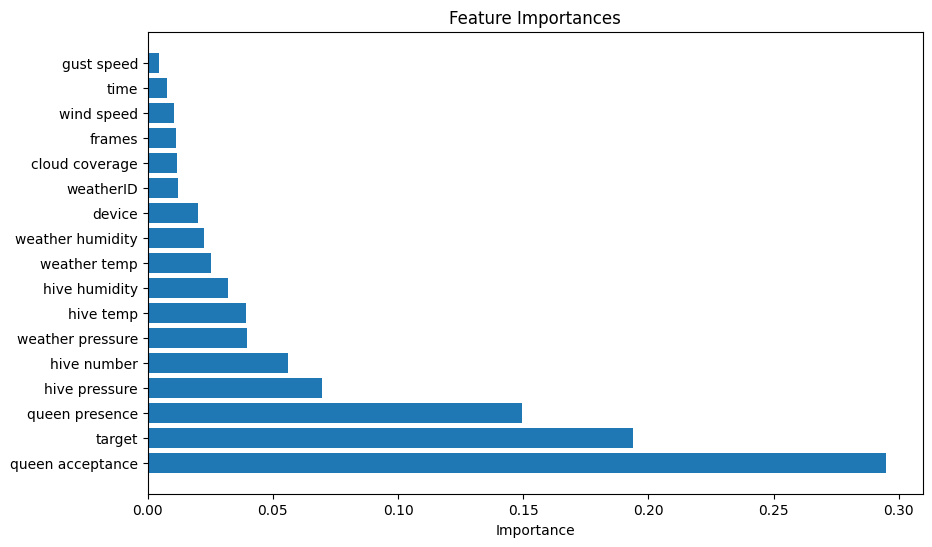

In [143]:
import matplotlib.pyplot as plt
import numpy as np

# Create a bar plot of feature importances
features = X_train.columns  # Get the column names of the features
importances = model.feature_importances_

# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), features[indices])
plt.xlabel('Importance')
plt.show()


In [144]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict on the test set
y_pred = model.predict(X_test)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       201
           1       1.00      1.00      1.00       197
           2       1.00      1.00      1.00       237
           3       1.00      1.00      1.00       381

    accuracy                           1.00      1016
   macro avg       1.00      1.00      1.00      1016
weighted avg       1.00      1.00      1.00      1016

Confusion Matrix:
[[201   0   0   0]
 [  0 197   0   0]
 [  0   0 237   0]
 [  0   0   0 381]]


In [145]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [146]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())


Cross-validation scores: [1.         1.         1.         1.         0.99876847]
Mean CV score: 0.9997536945812808


In [147]:
#reduce model complexity
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)
#limited depth (max_depth=10), reducing the complexity and preventing overfitting.

RandomForestClassifier(max_depth=10, random_state=42)

In [148]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=10)  # 10-fold CV
print(f"10-fold Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean()}")


10-fold Cross-validation scores: [0.98525799 0.99262899 0.99507389 0.98768473 0.98768473 0.99753695
 0.99507389 0.99261084 0.99014778 0.99014778]
Mean CV score: 0.9913847569019982


In [149]:
#calculates and prints the accuracy of the trained model on the test set (X_test and y_test)
test_accuracy = model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy}")


Test Accuracy: 0.9931102362204725


In [150]:
import pandas as pd

y_pred = model.predict(X_test)

# Create a DataFrame with the predictions
predictions_df = pd.DataFrame({'Predictions': y_pred})

# Save the predictions to a CSV file
predictions_df.to_csv('predictions.csv', index=False)


In [151]:
importances = model.feature_importances_

# Create a DataFrame for feature importances
feature_importances_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# Save to CSV
feature_importances_df.to_csv('feature_importances.csv', index=False)


In [167]:
import pickle
with open('hive_conditions_model.pkl', 'wb') as f:
    pickle.dump(model, f)


In [172]:
# Save the training data to CSV
df_cleaned.to_csv('train_data.csv', index=False)


In [176]:
# Assuming train is the DataFrame you want to modify
train = df_cleaned.copy()  # If train is not already defined

train['queen status'] = train['queen status'].replace({
    0: 'queen present or original queen',
    1: 'queen not present',
    2: 'queen present and rejected', 
    3: 'queen present and newly accepted'
})
train['queen status'] = train['queen status'].replace({
    0: 'queen present or original queen',
    1: 'queen not present',
    2: 'queen present and rejected', 
    3: 'queen present and newly accepted'
})

# Check the result
train.head()



,device,hive number,date,hive temp,hive humidity,hive pressure,weather temp,weather humidity,weather pressure,wind speed,...,weatherID,cloud coverage,file name,queen presence,queen acceptance,frames,target,time,queen status,mfcc_features
0,-1.153441,5,2022-06-08 14:52:28,36.42,-0.732695,-0.586876,1.0551,-0.614969,0.021768,2.030095,...,711,1.423845,2022-06-08--14-52-28_1.raw,1,0.779432,-1.153441,-1.794007,0.346315,queen present or original queen,[-237.3919 152.39178 26.215218 21.8...
1,-1.153441,5,2022-06-08 14:52:28,33.56,-0.732695,-0.586876,1.0551,-0.614969,0.021768,2.030095,...,711,1.423845,2022-06-08--14-52-28_1.raw,1,0.779432,-1.153441,-1.794007,0.346315,queen present or original queen,[-256.57846 176.46771 5.1267195 47.7...
2,-1.153441,5,2022-06-08 14:52:28,29.01,-0.732695,-0.586876,1.0551,-0.614969,0.021768,2.030095,...,711,1.423845,2022-06-08--14-52-28_1.raw,1,0.779432,-1.153441,-1.794007,0.346315,queen present or original queen,[-253.869 179.72514 2.5020776 48.2...
3,-1.153441,5,2022-06-08 14:52:28,30.51,-0.732695,-0.586876,1.0551,-0.614969,0.021768,2.030095,...,711,1.423845,2022-06-08--14-52-28_1.raw,1,0.779432,-1.153441,-1.794007,0.346315,queen present or original queen,[-262.1603 179.24033 7.655314 45.8...
4,-1.153441,5,2022-06-08 14:52:28,30.32,-0.732695,-0.586876,1.0551,-0.614969,0.021768,2.030095,...,711,1.423845,2022-06-08--14-52-28_1.raw,1,0.779432,-1.153441,-1.794007,0.346315,queen present or original queen,[-2.6435406e+02 1.7796187e+02 8.2750549e+00 ...


In [180]:
# Select only the 'file name' and 'queen status' columns
train = df_cleaned[['file name', 'queen status']]

# Replace the numeric values with the text labels in 'queen status'
train['queen status'] = train['queen status'].replace({
    0: 'queen present or original queen',
    1: 'queen not present',
    2: 'queen present and rejected', 
    3: 'queen present and newly accepted'
})

# Display the first few rows to verify
train.head(100)


C:\Users\kedri\AppData\Local\Temp\ipykernel_18976\418827201.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['queen status'] = train['queen status'].replace({


,file name,queen status
0,2022-06-08--14-52-28_1.raw,queen present or original queen
1,2022-06-08--14-52-28_1.raw,queen present or original queen
2,2022-06-08--14-52-28_1.raw,queen present or original queen
3,2022-06-08--14-52-28_1.raw,queen present or original queen
4,2022-06-08--14-52-28_1.raw,queen present or original queen
...,...,...
95,2022-06-09--06-11-16_1.raw,queen not present
96,2022-06-09--07-10-32_1.raw,queen not present
97,2022-06-09--07-10-32_1.raw,queen not present
98,2022-06-09--07-10-32_1.raw,queen not present
